In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [118]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

In [124]:
base_path = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset"

train_dir = base_path + "/train"
val_dir   = base_path + "/val"
test_dir  = base_path + "/test"

In [126]:
class CLAHETransform:
    def __call__(self, img):
        import numpy as np

        img = np.array(img)

        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img = clahe.apply(img)

        img = Image.fromarray(img)  # مهم جدًا
        return img

In [127]:
transform_train = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224,224)),
    transforms.Lambda(lambda x: x.convert("RGB")),  # حل 1→3 channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])
])

transform_val = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224,224)),
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])
])

In [128]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform_val)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform_val)

In [129]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [133]:

num_classes = 8

In [135]:
model = models.densenet121(pretrained=True)

# classifier
in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [139]:
# Freeze whole model
for param in model.parameters():
    param.requires_grad = False

# train only classifier
for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3)

In [140]:
epochs_stage1 = 3

for epoch in range(epochs_stage1):
    model.train()
    total_loss, correct = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()

    acc = correct / len(train_dataset)
    print(f"[Stage 1] Epoch {epoch+1} | Acc: {acc:.4f}")

[Stage 1] Epoch 1 | Acc: 0.7609
[Stage 1] Epoch 2 | Acc: 0.8032
[Stage 1] Epoch 3 | Acc: 0.8109


In [142]:
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

In [147]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=5e-3
)

In [149]:
epochs_stage2 = 5  # أو أي رقم أنتي عايزاه

In [ ]:
for epoch in range(epochs_stage2):

    # ================= TRAIN =================
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = out.argmax(1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_acc = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            preds = out.argmax(1)

            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(f"""
    Epoch {epoch+1}
    Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
    Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}
    """)


    Epoch 1
    Train Loss: 0.4218 | Train Acc: 0.8426
    Val Loss:   0.3488 | Val Acc:   0.8700
    

    Epoch 2
    Train Loss: 0.3693 | Train Acc: 0.8626
    Val Loss:   0.3124 | Val Acc:   0.8871
    

    Epoch 3
    Train Loss: 0.3294 | Train Acc: 0.8782
    Val Loss:   0.2876 | Val Acc:   0.8957
    

    Epoch 4
    Train Loss: 0.3123 | Train Acc: 0.8868
    Val Loss:   0.2729 | Val Acc:   0.8975
    

    Epoch 5
    Train Loss: 0.2895 | Train Acc: 0.8973
    Val Loss:   0.2626 | Val Acc:   0.9068
    


In [186]:
# Stage 3: Fine-tuning deeper layers
for param in model.features.denseblock3.parameters():
    param.requires_grad = True

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

In [189]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-6,
    weight_decay=1e-2
)

In [194]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        # لأننا بنراقب accuracy
    factor=0.5,
    patience=2,
)

In [195]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

In [196]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [202]:
import torch

class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc, model, path="best_model.pth"):

        # أول مرة
        if self.best_score is None:
            self.best_score = val_acc
            self.save_checkpoint(model, path)

        # لو مفيش تحسن كافي
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f" EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

        # لو في تحسن
        else:
            self.best_score = val_acc
            self.save_checkpoint(model, path)
            self.counter = 0
            print(" Model improved and saved!")

    def save_checkpoint(self, model, path):
        torch.save(model.state_dict(), path)


Epoch 1/10
Train Loss: 0.2178 | Train Acc: 0.9267
Val Loss:   0.2007 | Val Acc:   0.9311
LR: 5e-06
 Best model saved!

Epoch 2/10
Train Loss: 0.1978 | Train Acc: 0.9328
Val Loss:   0.1831 | Val Acc:   0.9350
LR: 5e-06
 Best model saved!
 Model improved and saved!

Epoch 3/10
Train Loss: 0.1843 | Train Acc: 0.9380
Val Loss:   0.1692 | Val Acc:   0.9379
LR: 5e-06
 Best model saved!
 Model improved and saved!

Epoch 4/10
Train Loss: 0.1731 | Train Acc: 0.9420
Val Loss:   0.1641 | Val Acc:   0.9393
LR: 5e-06
 Best model saved!
 Model improved and saved!

Epoch 5/10
Train Loss: 0.1653 | Train Acc: 0.9451
Val Loss:   0.1604 | Val Acc:   0.9411
LR: 5e-06
 Best model saved!
 Model improved and saved!

Epoch 6/10
Train Loss: 0.1576 | Train Acc: 0.9479
Val Loss:   0.1551 | Val Acc:   0.9446
LR: 5e-06
 Best model saved!
 Model improved and saved!

Epoch 7/10
Train Loss: 0.1522 | Train Acc: 0.9500
Val Loss:   0.1475 | Val Acc:   0.9446
LR: 5e-06
 Model improved and saved!

Epoch 8/10
Train Loss: 

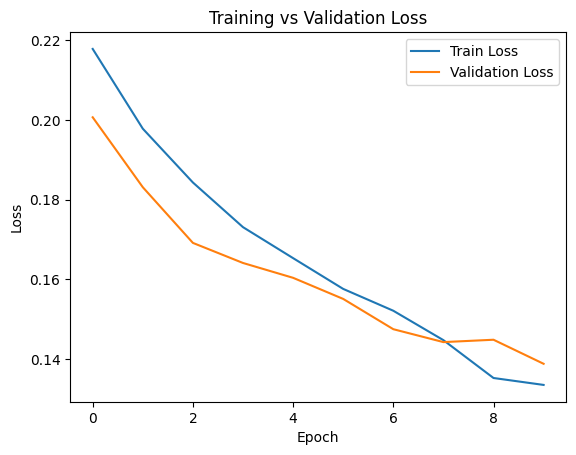

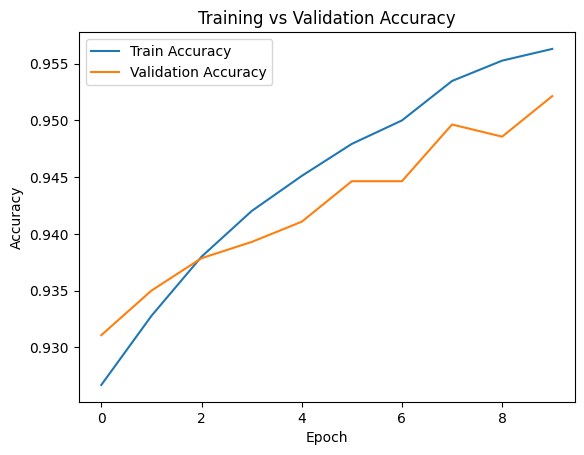

In [204]:
import torch
import copy
import matplotlib.pyplot as plt

num_epochs = 10
best_acc = 0.0

early_stopping = EarlyStopping(patience=4)

# ================= LISTS =================
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ================= TRAIN =================
    model.train()

    train_loss = 0
    train_correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = train_correct / total
    train_loss = train_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()

    val_loss = 0
    val_correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = val_correct / total
    val_loss = val_loss / len(val_loader)

    # ================= SAVE VALUES =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ================= SCHEDULER =================
    scheduler.step(val_acc)

    # ================= PRINT =================
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("LR:", optimizer.param_groups[0]['lr'])

    # ================= SAVE BEST MODEL =================
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(" Best model saved!")

    # ================= EARLY STOPPING =================
    early_stopping(val_acc, model)

    if early_stopping.early_stop:
        print(" Early stopping triggered")
        break

print("\nBest Validation Accuracy:", best_acc)

# ================= PLOTS =================

# Loss
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [233]:
from sklearn.metrics import classification_report
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# تحويل لقوائم numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# حساب الدقة
accuracy = (all_preds == all_labels).mean()
print("Test Accuracy:", accuracy)

# أسماء الكلاسات
class_names = test_dataset.classes

# طباعة التقرير
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.9521428571428572

Classification Report:

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.93      0.89      0.91       350
         CSR       1.00      1.00      1.00       350
         DME       0.93      0.92      0.92       350
          DR       1.00      1.00      1.00       350
      DRUSEN       0.90      0.84      0.87       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.87      0.97      0.92       350

    accuracy                           0.95      2800
   macro avg       0.95      0.95      0.95      2800
weighted avg       0.95      0.95      0.95      2800



In [230]:
import os
import zipfile

# فولدر للحفظ
output_dir = "test_outputs"
os.makedirs(output_dir, exist_ok=True)

# ================= 1. حفظ الـ Accuracy =================
with open(f"{output_dir}/accuracy.txt", "w") as f:
    f.write(f"Test Accuracy: {accuracy:.4f}")

# ================= 2. حفظ Confusion Matrix كـ CSV =================
import pandas as pd

cm_df = pd.DataFrame(cm)
cm_df.to_csv(f"{output_dir}/confusion_matrix.csv", index=False)

# ================= 3. حفظ Classification Report =================
report = classification_report(all_labels, all_preds)

with open(f"{output_dir}/classification_report.txt", "w") as f:
    f.write(report)

# ================= 4. حفظ الصورة (إنتي عملتيها بالفعل) =================
# لو لسه:
# plt.savefig(f"{output_dir}/confusion_matrix.png")

# ================= 5. ضغط كل الملفات =================
zip_path = "test_results.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    for file in os.listdir(output_dir):
        z.write(os.path.join(output_dir, file))

print("✅ كل النتائج اتحفظت في:", zip_path)

✅ كل النتائج اتحفظت في: test_results.zip


In [131]:
torch.save(model.state_dict(), "best_model.pth")